# Vitamin D Deficiency Prediction Model — Full Analysis

**Objective:** To predict 25-hydroxyvitamin D [25(OH)D] deficiency (<20 ng/mL) using non-laboratory (non-invasive) predictors.

This Google Colab notebook:

- Recreates the reported Python analysis environment with pinned package versions.
- Uploads the `data_for_py.csv` dataset into the Google Colab environment.
- Executes the analysis workflow sequentially in structured sections.
- Saves the resulting CSV tables and 300 DPI PNG figures to the `/content` folder.
- Compresses all generated outputs into a ZIP archive in the final cell for download.

**Reported Analysis Environment:**

- Python 3.11.15
- numpy 1.26.4
- pandas 3.0.3
- scikit-learn 1.9.0
- statsmodels 0.14.6
- xgboost 3.2.0
- catboost 1.2.7
- scipy 1.17.1
- matplotlib 3.11.0

A seed value of `seed = 42` was used for all random operations to ensure reproducibility.

> Run the cells sequentially from top to bottom. After the first setup cell, restart the runtime environment (Runtime > Restart session) and continue from the second cell.


In [1]:
# 1) Installation of required libraries with pinned versions
# Library versions are pinned to recreate the exact environment reported in the study.

%pip install -q --upgrade --force-reinstall \
    numpy==1.26.4 \
    pandas==3.0.3 \
    scipy==1.17.1 \
    matplotlib==3.11.0 \
    scikit-learn==1.9.0 \
    statsmodels==0.14.6 \
    xgboost==3.2.0 \
    catboost==1.2.7

print("Library installation completed.")
print("IMPORTANT: Restart the runtime session via 'Runtime > Restart session' in the menu.")
print("After restarting, proceed from cell 2.")


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 3.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 3.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.1/62.1 kB 2.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 4.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.7/118.7 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 53.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 46.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.2/35.2 MB 10.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 58.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 38.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.3/10.3 MB 51.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.7/131.7 MB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.

## 2) Verification of the Analysis Environment

In [1]:
# Verification of the installed library versions
import platform
import numpy as np
import pandas as pd
import sklearn
import statsmodels
import xgboost
import catboost
import scipy
import matplotlib

expected_versions = {
    "python": "3.11.15",
    "numpy": "1.26.4",
    "pandas": "3.0.3",
    "scikit-learn": "1.9.0",
    "statsmodels": "0.14.6",
    "xgboost": "3.2.0",
    "catboost": "1.2.7",
    "scipy": "1.17.1",
    "matplotlib": "3.11.0",
}

installed_versions = {
    "python": platform.python_version(),
    "numpy": np.__version__,
    "pandas": pd.__version__,
    "scikit-learn": sklearn.__version__,
    "statsmodels": statsmodels.__version__,
    "xgboost": xgboost.__version__,
    "catboost": catboost.__version__,
    "scipy": scipy.__version__,
    "matplotlib": matplotlib.__version__,
}

version_table = pd.DataFrame({
    "library": installed_versions.keys(),
    "installed": installed_versions.values(),
    "expected": expected_versions.values(),
})
version_table["match"] = version_table["installed"] == version_table["expected"]
display(version_table)

if not version_table["match"].all():
    print("WARNING: Some library versions do not match the expected environment.")
    print("Please run the installation cell again and restart the runtime session.")
else:
    print("All library versions match the reported analysis environment successfully.")


,library,installed,expected,match
0,python,3.12.13,3.11.15,False
1,numpy,1.26.4,1.26.4,True
2,pandas,3.0.3,3.0.3,True
3,scikit-learn,1.9.0,1.9.0,True
4,statsmodels,0.14.6,0.14.6,True
5,xgboost,3.2.0,3.2.0,True
6,catboost,1.2.7,1.2.7,True
7,scipy,1.17.1,1.17.1,True
8,matplotlib,3.11.0,3.11.0,True


Please run the installation cell again and restart the runtime session.


In [2]:
# 3) Upload the 'data_for_py.csv' dataset to the Google Colab environment
from google.colab import files
uploaded = files.upload()

assert "data_for_py.csv" in uploaded, (
    "Please make sure that the uploaded file is named exactly 'data_for_py.csv'."
)
print("data_for_py.csv uploaded successfully.")


Saving data_for_py.csv to data_for_py.csv
data_for_py.csv uploaded successfully.


## 3) Imports, Global Settings, and Version Provenance

In [3]:
# -*- coding: utf-8 -*-
# =============================================================================
# VITAMIN D DEFICIENCY (25(OH)D < 20 ng/mL) PREDICTION MODEL — FULL ANALYSIS
# =============================================================================
# This script constructs a Logistic Regression (LR) model using non-laboratory
# predictors (age, sex, BMI, vitamin D supplementation, and cyclical sin/cos
# components of the day of year) to predict Vitamin D deficiency. It compares
# LR with four machine learning models. Reporting complies with the TRIPOD+AI
# guidelines.
#
# REPRODUCIBILITY: All random processes are locked with seed=42 (train/test split,
# cross-validation splits, model initializations). Library versions are saved
# to 'versiyon_kunyesi.csv'.
# =============================================================================

import platform, json, warnings
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import mannwhitneyu, chi2_contingency
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (roc_auc_score, brier_score_loss, f1_score,
                             roc_curve, confusion_matrix)
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
import statsmodels.api as sm
from statsmodels.nonparametric.smoothers_lowess import lowess
warnings.filterwarnings("ignore")

SEED = 42
plt.rcParams.update({"font.size":11, "axes.spines.top":False,
                     "axes.spines.right":False, "savefig.bbox":"tight"})
MAVI, KIRMIZI = "#1f4e79", "#c0504d"  # Protective / Risk colors

import sklearn, statsmodels, xgboost, catboost, scipy, matplotlib
pd.DataFrame({
    "library":["python","numpy","pandas","scikit-learn","statsmodels",
               "xgboost","catboost","scipy","matplotlib"],
    "version":[platform.python_version(), np.__version__, pd.__version__,
               sklearn.__version__, statsmodels.__version__, xgboost.__version__,
               catboost.__version__, scipy.__version__, matplotlib.__version__]
}).to_csv("versiyon_kunyesi.csv", index=False)

print("Imports and version provenance completed.")


Imports and version provenance completed.


## 4) Data Loading and Feature Encoding

In [4]:
d = pd.read_csv("data_for_py.csv")
# Yas: Age, Sex_Female: Female (1=Yes, 0=No), BMI: Body Mass Index, Supp_Yes: Supplementation (1=Yes, 0=No)
# sin_gun / cos_gun: Cyclical components representing day of the year
feat = ["Yas","Sex_Female","BMI","Supp_Yes","sin_gun","cos_gun"]
cont = ["Yas","BMI","sin_gun","cos_gun"]
X, y = d[feat].copy(), d["y"].values

print("Dataset dimensions:", d.shape)
display(d.head())


Dataset dimensions: (1768, 7)


,Yas,Sex_Female,BMI,Supp_Yes,sin_gun,cos_gun,y
0,40,1,23.0,0,0.05162,0.998667,1
1,33,1,24.0,0,0.05162,0.998667,1
2,42,1,24.0,0,0.05162,0.998667,1
3,37,1,36.0,1,0.05162,0.998667,1
4,61,1,23.0,0,0.05162,0.998667,1


## 5) Table 1 — Baseline Characteristics

In [5]:
# Baseline comparisons between deficient (y=1, <20 ng/mL) and sufficient (y=0, >=20 ng/mL) cohorts
dfd, dfs = d[d.y==1], d[d.y==0]
miqr = lambda x: "%.1f [%.1f-%.1f]" % (x.median(), x.quantile(.25), x.quantile(.75))
def p_fmt(p): return "<0.001" if p<0.001 else "%.3f"%p
r1=[]
for v,l in [("Yas","Age, years"),("BMI","BMI, kg/m2"),("sin_gun","sin_day"),("cos_gun","cos_day")]:
    p=mannwhitneyu(dfd[v],dfs[v]).pvalue
    r1.append([l,miqr(dfd[v]),miqr(dfs[v]),p_fmt(p)])
for l,c in [("Female, n (%)","Sex_Female"),("Vitamin D supplement (yes), n (%)","Supp_Yes")]:
    a,b=int(dfd[c].sum()),int(dfs[c].sum())
    p=chi2_contingency([[a,len(dfd)-a],[b,len(dfs)-b]])[1]
    r1.append([l,"%d (%.1f)"%(a,100*a/len(dfd)),"%d (%.1f)"%(b,100*b/len(dfs)),p_fmt(p)])
table1 = pd.DataFrame(r1,columns=["Parameter",f"Deficient <20 ng/mL (n={len(dfd)})",
    f"Sufficient >=20 ng/mL (n={len(dfs)})","p"])
table1.to_csv("table1_baseline.csv",index=False)
display(table1)


,Parameter,Deficient <20 ng/mL (n=811),Sufficient >=20 ng/mL (n=957),p
0,"Age, years",41.0 [30.0-52.0],47.0 [37.0-56.0],<0.001
1,"BMI, kg/m2",27.3 [24.2-32.0],26.4 [23.4-30.1],<0.001
2,sin_day,0.4 [-0.3-0.8],-0.1 [-0.7-0.6],<0.001
3,cos_day,0.0 [-0.8-0.8],-0.2 [-0.8-0.5],<0.001
4,"Female, n (%)",667 (82.2),758 (79.2),0.121
5,"Vitamin D supplement (yes), n (%)",30 (3.7),451 (47.1),<0.001


## 6) Train/Test Split, Feature Scaling, and Table 2

In [6]:
# Stratified 70/30 split and standard scaling fit only on the training set
Xtr,Xte,ytr,yte = train_test_split(X,y,test_size=0.30,random_state=SEED,stratify=y)
scaler = StandardScaler().fit(Xtr[cont])
Xtr_s, Xte_s = Xtr.copy(), Xte.copy()
Xtr_s[cont] = scaler.transform(Xtr[cont]); Xte_s[cont] = scaler.transform(Xte[cont])
json.dump({"mu":scaler.mean_.tolist(),"sd":scaler.scale_.tolist(),"cont":cont},
          open("scaler.json","w"))
Xtr_np, Xte_np = Xtr_s.values, Xte_s.values

# Generate Table 2 to verify split homogeneity (all p-values should be > 0.05)
tr=Xtr.copy(); tr["y"]=ytr; te=Xte.copy(); te["y"]=yte; alld=X.copy(); alld["y"]=y
r2=[]
for v,l in [("Yas","Age, years"),("BMI","BMI, kg/m2"),("sin_gun","sin_day"),("cos_gun","cos_day")]:
    p=mannwhitneyu(tr[v],te[v]).pvalue
    r2.append([l,miqr(alld[v]),miqr(tr[v]),miqr(te[v]),"%.3f"%p])
for l,c in [("Female, n (%)","Sex_Female"),("Vitamin D supplement (yes), n (%)","Supp_Yes")]:
    a,b=int(tr[c].sum()),int(te[c].sum())
    p=chi2_contingency([[a,len(tr)-a],[b,len(te)-b]])[1]
    r2.append([l,"%d (%.1f)"%(int(alld[c].sum()),100*alld[c].mean()),
               "%d (%.1f)"%(a,100*a/len(tr)),"%d (%.1f)"%(b,100*b/len(te)),"%.3f"%p])
a,b=int(ytr.sum()),int(yte.sum())
r2.append(["25(OH)D <20, n (%)","%d (%.1f)"%(int(y.sum()),100*y.mean()),
           "%d (%.1f)"%(a,100*a/len(tr)),"%d (%.1f)"%(b,100*b/len(te)),
           "%.3f"%chi2_contingency([[a,len(tr)-a],[b,len(te)-b]])[1]])
table2 = pd.DataFrame(r2,columns=["Variable","All (n=1768)",f"Training (n={len(tr)})",
    f"Test (n={len(te)})","p"])
table2.to_csv("table2_split.csv",index=False)
display(table2)


,Variable,All (n=1768),Training (n=1237),Test (n=531),p
0,"Age, years",45.0 [33.0-55.0],45.0 [33.0-55.0],45.0 [34.0-55.0],0.820
1,"BMI, kg/m2",26.7 [23.7-30.9],26.8 [23.9-31.1],26.6 [23.6-30.5],0.297
2,sin_day,0.1 [-0.6-0.7],0.2 [-0.5-0.7],0.1 [-0.7-0.7],0.102
3,cos_day,-0.2 [-0.8-0.7],-0.2 [-0.8-0.7],-0.1 [-0.8-0.6],0.532
4,"Female, n (%)",1425 (80.6),997 (80.6),428 (80.6),1.000
5,"Vitamin D supplement (yes), n (%)",481 (27.2),344 (27.8),137 (25.8),0.417
6,"25(OH)D <20, n (%)",811 (45.9),567 (45.8),244 (46.0),1.000


## 7) Model Training and Optimization

In [7]:
# 5-fold cross-validation setup for hyperparameter search
cv = StratifiedKFold(5, shuffle=True, random_state=SEED)
M = {}
M["Logistic regression"] = LogisticRegression(max_iter=1000,random_state=SEED).fit(Xtr_np,ytr)
M["SVM"] = GridSearchCV(SVC(probability=True,random_state=SEED),{"C":[0.5,1,2]},
                        cv=cv,scoring="roc_auc",n_jobs=1).fit(Xtr_np,ytr).best_estimator_
M["Random forest"] = GridSearchCV(RandomForestClassifier(random_state=SEED),
    {"n_estimators":[300],"max_depth":[4,6,8]},cv=cv,scoring="roc_auc",n_jobs=1).fit(Xtr_np,ytr).best_estimator_
M["XGBoost"] = GridSearchCV(XGBClassifier(eval_metric="logloss",random_state=SEED,verbosity=0,n_jobs=1),
    {"n_estimators":[200],"max_depth":[3,4],"learning_rate":[0.05,0.1]},cv=cv,scoring="roc_auc",n_jobs=1).fit(Xtr_np,ytr).best_estimator_
cat_fn = lambda: CatBoostClassifier(iterations=300,depth=4,learning_rate=0.05,
                                    random_seed=SEED,verbose=0,thread_count=1)
M["CatBoost"] = cat_fn().fit(Xtr_np,ytr)
print("Models successfully trained:", list(M))


Models successfully trained: ['Logistic regression', 'SVM', 'Random forest', 'XGBoost', 'CatBoost']


## 8) Bootstrapping, Cross-Validation, and Table 3 (Performance Metrics)

In [8]:
# Compute 95% bootstrap confidence intervals for the test set AUC
def boot_ci(yt,pp,n=1000):
    rng=np.random.default_rng(SEED); b=[]
    for _ in range(n):
        i=rng.integers(0,len(yt),len(yt))
        if len(np.unique(yt[i]))>1: b.append(roc_auc_score(yt[i],pp[i]))
    return np.percentile(b,[2.5,97.5])

# Compute 95% confidence intervals for 5-fold cross-validation AUC
def cv_ci(m,Xa,ya,manual=False):
    if manual:
        aucs=[roc_auc_score(ya[vi],cat_fn().fit(Xa[ti],ya[ti]).predict_proba(Xa[vi])[:,1])
              for ti,vi in cv.split(Xa,ya)]; aucs=np.array(aucs)
    else:
        aucs=cross_val_score(m,Xa,ya,cv=cv,scoring="roc_auc")
    h=aucs.std(ddof=1)/np.sqrt(len(aucs))*stats.t.ppf(0.975,len(aucs)-1)
    return aucs.mean(),aucs.mean()-h,aucs.mean()+h

probas, rocs, r3 = {}, {}, []
for name,m in M.items():
    pte=m.predict_proba(Xte_np)[:,1]; probas[name]=pte
    cvm,cl,ch=cv_ci(m,Xtr_np,ytr,manual=(name=="CatBoost"))
    auc=roc_auc_score(yte,pte); lo,hi=boot_ci(yte,pte)
    fpr,tpr,thr=roc_curve(yte,pte); t=thr[np.argmax(tpr-fpr)]
    pred=(pte>=t).astype(int); tn,fp,fn,tp=confusion_matrix(yte,pred).ravel()
    r3.append([name,"%.3f [%.3f-%.3f]"%(cvm,cl,ch),"%.3f [%.3f-%.3f]"%(auc,lo,hi),
               "%.3f"%brier_score_loss(yte,pte),"%.3f"%(tp/(tp+fn)),
               "%.3f"%(tn/(tn+fp)),"%.3f"%f1_score(yte,pred)])
    rocs[name]=(fpr,tpr,auc)
table3 = pd.DataFrame(r3,columns=["Model","CV AUC (95% CI)","Test AUC (95% CI)","Brier",
    "Sensitivity","Specificity","F1 score"]).sort_values("Test AUC (95% CI)",ascending=False)
table3.to_csv("table3_performance.csv",index=False)
display(table3)


,Model,CV AUC (95% CI),Test AUC (95% CI),Brier,Sensitivity,Specificity,F1 score
0,Logistic regression,0.806 [0.767-0.846],0.832 [0.794-0.869],0.164,0.873,0.690,0.780
4,CatBoost,0.782 [0.747-0.817],0.823 [0.784-0.858],0.169,0.807,0.721,0.756
3,XGBoost,0.782 [0.746-0.817],0.819 [0.779-0.855],0.171,0.811,0.704,0.751
2,Random forest,0.796 [0.760-0.833],0.817 [0.777-0.855],0.173,0.848,0.714,0.777
1,SVM,0.794 [0.747-0.840],0.811 [0.772-0.850],0.169,0.775,0.780,0.762


## 9) DeLong's Hypothesis Test and ROC Curve Comparison

,Logistic regression,SVM,Random forest,XGBoost,CatBoost
Logistic regression,—,0.007,0.008,0.090,0.250
SVM,0.007,—,0.413,0.403,0.194
Random forest,0.008,0.413,—,0.798,0.426
XGBoost,0.090,0.403,0.798,—,0.444
CatBoost,0.250,0.194,0.426,0.444,—


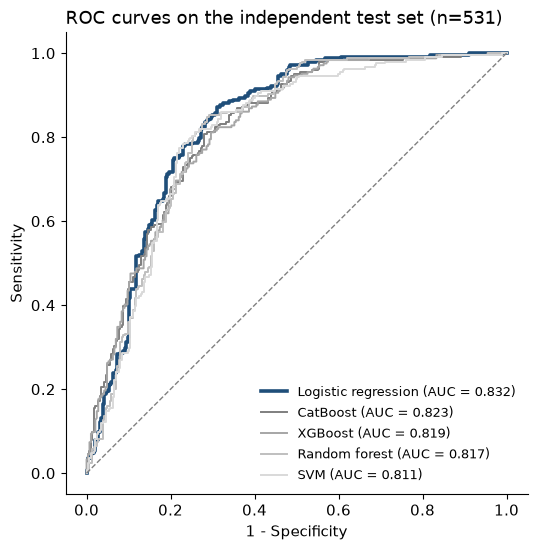

In [9]:
# DeLong's test implementation (Sun & Xu 2014 fast algorithm) for statistical significance between ROC curves
def _midrank(x):
    J=np.argsort(x); Z=x[J]; N=len(x); T=np.zeros(N); i=0
    while i<N:
        j=i
        while j<N and Z[j]==Z[i]: j+=1
        T[i:j]=0.5*(i+j-1)+1; i=j
    T2=np.empty(N); T2[J]=T; return T2

def delong(y_,p1,p2):
    o=np.argsort(-y_); ys=y_[o]; m=int(ys.sum())
    ps=np.vstack([p1[o],p2[o]]); n=ps.shape[1]-m
    tx=np.array([_midrank(ps[r,:m]) for r in range(2)])
    ty=np.array([_midrank(ps[r,m:]) for r in range(2)])
    tz=np.array([_midrank(ps[r]) for r in range(2)])
    aucs=(tz[:,:m].sum(1)/m-(m+1)/2)/n
    v01=(tz[:,:m]-tx)/n; v10=1-(tz[:,m:]-ty)/m
    cov=np.cov(v01)/m+np.cov(v10)/n
    z=(aucs[0]-aucs[1])/np.sqrt(np.array([[1,-1]])@cov@np.array([[1],[-1]]))[0,0]
    return z, 2*stats.norm.sf(abs(z))

nm=["Logistic regression"]+[k for k in probas if k!="Logistic regression"]
mat=pd.DataFrame(index=nm,columns=nm,dtype=object)
for a in nm:
    for b in nm:
        mat.loc[a,b]="—" if a==b else "%.3f"%delong(yte,probas[a],probas[b])[1]
mat.to_csv("table4_delong.csv")
display(mat)

# Plot ROC curves comparing the primary Logistic Regression model with machine learning models
cols={"Logistic regression":MAVI,"CatBoost":"#7f7f7f","XGBoost":"#a6a6a6",
      "Random forest":"#bfbfbf","SVM":"#d9d9d9"}
fig,ax=plt.subplots(figsize=(6,6))
for n in sorted(rocs,key=lambda k:-rocs[k][2]):
    fpr,tpr,auc=rocs[n]
    ax.plot(fpr,tpr,color=cols[n],lw=2.6 if n=="Logistic regression" else 1.4,
            label=f"{n} (AUC = {auc:.3f})")
ax.plot([0,1],[0,1],"--",color="grey",lw=1)
ax.set_xlabel("1 - Specificity"); ax.set_ylabel("Sensitivity")
ax.set_title("ROC curves on the independent test set (n=531)",loc="left")
ax.set_aspect("equal"); ax.legend(loc="lower right",frameon=False,fontsize=9.5)
fig.savefig("fig2_roc.png",dpi=300,facecolor="white")
plt.show()
plt.close(fig)


## 10) Logistic Regression Calibration Curve

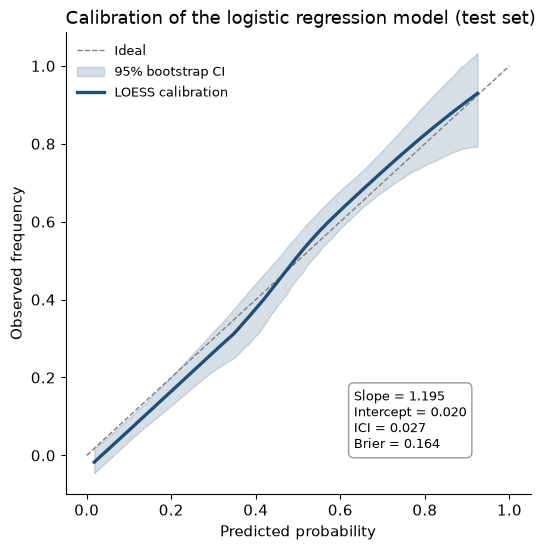

In [10]:
# Compute Logistic Regression calibration statistics: slope, intercept, ICI, and Brier Score
p_lr=probas["Logistic regression"]; eps=1e-9
lp=np.log(np.clip(p_lr,eps,1-eps)/(1-np.clip(p_lr,eps,1-eps)))
cal_slope=sm.Logit(yte,sm.add_constant(lp)).fit(disp=0).params[1]
cal_int=sm.Logit(yte,np.ones_like(lp),offset=lp).fit(disp=0).params[0]
lo=lowess(yte,p_lr,frac=0.75,it=0,return_sorted=True)
cal_pred=np.interp(p_lr,lo[:,0],lo[:,1]); ad=np.abs(cal_pred-p_lr)
ICI,E90,Emax=ad.mean(),np.percentile(ad,90),ad.max()
pd.DataFrame([["Calibration slope",cal_slope],["Calibration intercept",cal_int],
    ["ICI",ICI],["E90",E90],["Emax",Emax],["Brier",brier_score_loss(yte,p_lr)]],
    columns=["Metric","Value"]).to_csv("calibration_metrics.csv",index=False)

# Bootstrap 95% confidence intervals for LOESS calibration curve
rng=np.random.default_rng(SEED); grid=np.linspace(p_lr.min(),p_lr.max(),200)
band=np.array([np.interp(grid,*lowess(yte[i:=rng.integers(0,len(yte),len(yte))],
    p_lr[i],frac=0.75,it=0,return_sorted=True).T) for _ in range(1000)])
fig,ax=plt.subplots(figsize=(6,6))
ax.plot([0,1],[0,1],"--",color="grey",lw=1,label="Ideal")
ax.fill_between(grid,np.percentile(band,2.5,0),np.percentile(band,97.5,0),
                color=MAVI,alpha=0.18,label="95% bootstrap CI")
ax.plot(grid,np.interp(grid,lo[:,0],lo[:,1]),color=MAVI,lw=2.4,label="LOESS calibration")
ax.set_xlabel("Predicted probability"); ax.set_ylabel("Observed frequency")
ax.set_title("Calibration of the logistic regression model (test set)",loc="left")
ax.legend(loc="upper left",frameon=False,fontsize=9.5)
ax.text(0.62,0.10,f"Slope = {cal_slope:.3f}\nIntercept = {cal_int:.3f}\n"
        f"ICI = {ICI:.3f}\nBrier = {brier_score_loss(yte,p_lr):.3f}",
        transform=ax.transAxes,fontsize=9.5,
        bbox=dict(boxstyle="round,pad=0.4",fc="white",ec="grey",alpha=0.8))
fig.savefig("fig3_calibration.png",dpi=300,facecolor="white")
plt.show()
plt.close(fig)


## 11) Decision Curve Analysis (DCA)

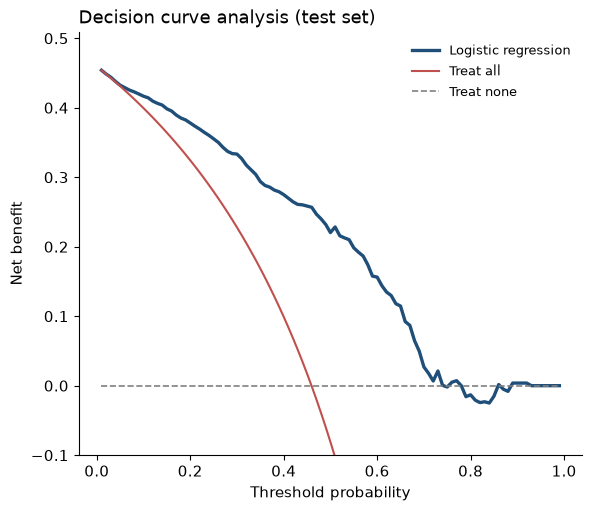

In [11]:
# Compute Net Benefit curves for Decision Curve Analysis (DCA)
pts=np.linspace(0.01,0.99,99); N=len(yte); prev=yte.mean()
nb_m=[( (p_lr>=t).astype(int)@(yte==1))/N-(((p_lr>=t)&(yte==0)).sum()/N)*(t/(1-t)) for t in pts]
nb_all=[prev-(1-prev)*(t/(1-t)) for t in pts]
fig,ax=plt.subplots(figsize=(6.5,5.5))
ax.plot(pts,nb_m,color=MAVI,lw=2.4,label="Logistic regression")
ax.plot(pts,nb_all,color=KIRMIZI,lw=1.5,label="Treat all")
ax.plot(pts,np.zeros_like(pts),"--",color="grey",lw=1.2,label="Treat none")
ax.set_xlabel("Threshold probability"); ax.set_ylabel("Net benefit")
ax.set_title("Decision curve analysis (test set)",loc="left")
ax.set_ylim(-0.1,prev+0.05); ax.legend(loc="upper right",frameon=False,fontsize=9.5)
fig.savefig("fig4_dca.png",dpi=300,facecolor="white")
plt.show()
plt.close(fig)


## 12) Logistic Regression Coefficients and Feature Importance

,Variable,Coefficient (beta),SE,Odds ratio,95% CI (OR),p
0,Intercept,0.061,0.150,1.063,0.793-1.425,0.685
1,Age (std),-0.399,0.072,0.671,0.583-0.772,<0.001
2,Sex (Female),0.439,0.169,1.551,1.113-2.161,0.009
3,BMI (std),0.378,0.073,1.459,1.265-1.684,<0.001
4,Vitamin D supplement,-2.975,0.224,0.051,0.033-0.079,<0.001
5,sin_day (std),0.491,0.072,1.634,1.420-1.880,<0.001
6,cos_day (std),0.218,0.067,1.244,1.091-1.419,0.001


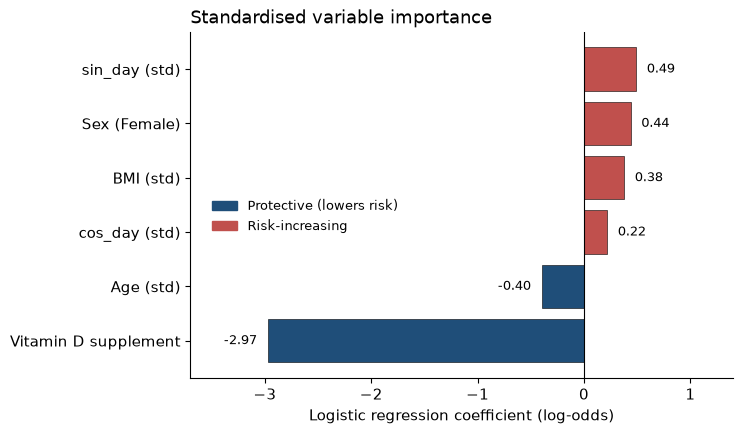

In [12]:
# Fit model using statsmodels.Logit on training set to obtain coefficients and standard errors
logit=sm.Logit(ytr,sm.add_constant(Xtr_s[feat].values)).fit(disp=0)
nm5=["Intercept","Age (std)","Sex (Female)","BMI (std)","Vitamin D supplement",
     "sin_day (std)","cos_day (std)"]
beta,se,pv=logit.params,logit.bse,logit.pvalues; ci=logit.conf_int()
table5 = pd.DataFrame([[nm5[i],"%.3f"%beta[i],"%.3f"%se[i],"%.3f"%np.exp(beta[i]),
    "%.3f-%.3f"%(np.exp(ci[i,0]),np.exp(ci[i,1])),p_fmt(pv[i])] for i in range(len(nm5))],
    columns=["Variable","Coefficient (beta)","SE","Odds ratio","95% CI (OR)","p"])
table5.to_csv("table5_coefficients.csv",index=False)
display(table5)

# Standardized variable importance based on log-odds coefficients
imp=pd.DataFrame({"var":nm5[1:],"beta":beta[1:]}).sort_values("beta")
fig,ax=plt.subplots(figsize=(7,4.5))
ax.barh(imp["var"],imp["beta"],color=np.where(imp["beta"]<0,MAVI,KIRMIZI),edgecolor="black",lw=0.4)
ax.axvline(0,color="black",lw=0.8)
for _,r in imp.iterrows():
    ax.text(r["beta"]+(-0.10 if r["beta"]<0 else 0.10),r["var"],"%.2f"%r["beta"],
            va="center",ha="right" if r["beta"]<0 else "left",fontsize=9.5)
ax.set_xlabel("Logistic regression coefficient (log-odds)")
ax.set_title("Standardised variable importance",loc="left"); ax.set_xlim(-3.7,1.4)
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color=MAVI,label="Protective (lowers risk)"),
    Patch(color=KIRMIZI,label="Risk-increasing")],loc="upper left",
    frameon=False,fontsize=9,bbox_to_anchor=(0.02,0.55))
fig.savefig("fig5_importance.png",dpi=300,facecolor="white")
plt.show()
plt.close(fig)


## 13) Supplementary Analyses (Goodness-of-Fit & Model Ablation)

In [13]:
# Pseudo-R2 metrics and comparison between cyclical vs. categorical seasonality representation
ll,ll0=logit.llf,sm.Logit(ytr,np.ones_like(ytr)).fit(disp=0).llf; n=len(ytr)
mcf=1-ll/ll0; cs=1-np.exp((2/n)*(ll0-ll)); nag=cs/(1-np.exp(2*ll0/n))
J=((np.arctan2(d.sin_gun,d.cos_gun)/(2*np.pi)*365).round().astype(int)%365).replace(0,365)
sea=J.apply(lambda j:"Spring" if 80<=j<172 else "Summer" if 172<=j<264 else
            "Autumn" if 264<=j<355 else "Winter")
sead=pd.get_dummies(sea,drop_first=True).astype(float)

# Function to fit sub-models for seasonality and supplement ablation analysis
def fit_auc(Xf):
    a,b,c,e=train_test_split(Xf,y,test_size=0.30,random_state=SEED,stratify=y)
    cc=[k for k in cont if k in Xf.columns]; s=StandardScaler().fit(a[cc])
    a,b=a.copy(),b.copy(); a[cc]=s.transform(a[cc]); b[cc]=s.transform(b[cc])
    m=LogisticRegression(max_iter=1000,random_state=SEED).fit(a.values,c)
    return roc_auc_score(c,m.predict_proba(a.values)[:,1]),\
           roc_auc_score(e,m.predict_proba(b.values)[:,1]),m.predict_proba(b.values)[:,1],e
base=["Yas","Sex_Female","BMI","Supp_Yes"]
ct1,ce1,pc1,yc1=fit_auc(d[base+["sin_gun","cos_gun"]])                      # Cyclical model (proposed)
ct2,ce2,pc2,yc2=fit_auc(pd.concat([d[base],sead],axis=1))                  # Categorical model (seasons)
zc,pcv=delong(yc1,pc1,pc2)
_,ab,_,_=fit_auc(d[["Yas","Sex_Female","BMI","sin_gun","cos_gun"]])        # Ablation: no supplement feature
supp = pd.DataFrame([["McFadden R2","%.4f"%mcf],["Cox & Snell R2","%.4f"%cs],
    ["Nagelkerke R2","%.4f"%nag],["Cyclical model test AUC","%.4f"%ce1],
    ["Categorical (season) test AUC","%.4f"%ce2],["DeLong cyclical vs categ. (p)","%.4f"%pcv],
    ["Ablation full test AUC","%.4f"%ce1],["Ablation no-supplement AUC","%.4f"%ab],
    ["Ablation AUC drop","%.4f"%(ce1-ab)]],columns=["Analysis","Value"])
supp.to_csv("table_supplementary.csv",index=False)
display(supp)


,Analysis,Value
0,McFadden R2,0.2548
1,Cox & Snell R2,0.2963
2,Nagelkerke R2,0.3960
3,Cyclical model test AUC,0.8322
4,Categorical (season) test AUC,0.8267
5,DeLong cyclical vs categ. (p),0.3168
6,Ablation full test AUC,0.8322
7,Ablation no-supplement AUC,0.6958
8,Ablation AUC drop,0.1364


## 14) Risk Stratification and Cutoff Rules

In [14]:
# Derive the optimal Youden's Index threshold on the training set and apply to the test set
ptr=M["Logistic regression"].predict_proba(Xtr_np)[:,1]
fptr,tptr,thtr=roc_curve(ytr,ptr); youden=thtr[np.argmax(tptr-fptr)]
def strat(t):
    pred=(p_lr>=t).astype(int); tn,fp,fn,tp=confusion_matrix(yte,pred).ravel()
    return ["%.3f"%t,"%.1f"%(100*tp/(tp+fn)),"%.1f"%(100*tn/(tn+fp)),
            "%.1f"%(100*tp/(tp+fp)),"%.1f"%(100*tn/(tn+fn)),
            "%.1f"%(100*(tp+tn)/len(yte)),tp,fp,tn,fn]
table6 = pd.DataFrame([["Low-risk rule-out (<0.20)"]+strat(0.20),
    ["Youden-optimal (training-derived)"]+strat(youden),
    ["Very-high-risk rule-in (>=0.80)"]+strat(0.80)],
    columns=["Risk stratum","Cutoff","Sensitivity %","Specificity %","PPV %",
             "NPV %","Accuracy %","TP","FP","TN","FN"])
table6.to_csv("table6_riskstrata.csv",index=False)
display(table6)

print("All analyses completed successfully. Tables (CSV) and figures (PNG) have been generated.")
print("LR test AUC = %.3f | Youden threshold (derived from training) = %.3f" %
      (roc_auc_score(yte,p_lr), youden))


,Risk stratum,Cutoff,Sensitivity %,Specificity %,PPV %,NPV %,Accuracy %,TP,FP,TN,FN
0,Low-risk rule-out (<0.20),0.200,98.0,46.7,61.0,96.4,70.2,239,153,134,5
1,Youden-optimal (training-derived),0.493,82.0,72.5,71.7,82.5,76.8,200,79,208,44
2,Very-high-risk rule-in (>=0.80),0.800,11.9,96.9,76.3,56.4,57.8,29,9,278,215


All analyses completed successfully. Tables (CSV) and figures (PNG) have been generated.
LR test AUC = 0.832 | Youden threshold (derived from training) = 0.493


## 15) List Generated Output Files and Compress to ZIP Archive

In [15]:
from pathlib import Path
import zipfile
from google.colab import files

# Identify generated table and figure outputs in the Colab directory
output_patterns = ["*.csv", "*.png", "*.json"]
output_files = sorted({
    p for pattern in output_patterns
    for p in Path("/content").glob(pattern)
    if p.name != "data_for_py.csv"
})

print("Generated output files:")
for p in output_files:
    print(" -", p.name)

# Compress files into a ZIP archive for easy download from Google Colab
zip_path = Path("/content/vitamin_d_analysis_outputs.zip")
with zipfile.ZipFile(zip_path, "w", compression=zipfile.ZIP_DEFLATED) as zf:
    for p in output_files:
        zf.write(p, arcname=p.name)

print("\nZIP archive prepared:", zip_path.name)
files.download(str(zip_path))


Generated output files:
 - calibration_metrics.csv
 - fig2_roc.png
 - fig3_calibration.png
 - fig4_dca.png
 - fig5_importance.png
 - scaler.json
 - table1_baseline.csv
 - table2_split.csv
 - table3_performance.csv
 - table4_delong.csv
 - table5_coefficients.csv
 - table6_riskstrata.csv
 - table_supplementary.csv
 - versiyon_kunyesi.csv

ZIP archive prepared: vitamin_d_analysis_outputs.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>